# <center><font color='color'>Sentimental Analysis of Amazon Product Review </font></center>

## Packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
import numpy as np
import seaborn as sns


from sklearn import datasets
from sklearn.model_selection import StratifiedShuffleSplit
import math
from sklearn.linear_model import LogisticRegression  #LogisticRegression


from sklearn.pipeline import Pipeline                # Pipeline



from sklearn.ensemble import RandomForestClassifier  #RandomForestClassifier 
from sklearn.svm import LinearSVC                    #LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn import metrics


## NLP 
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
 



import warnings
warnings.filterwarnings('ignore') 
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore",category=UserWarning)
sns.set_style("whitegrid") 

%matplotlib inline
np.random.seed(7) 

## Read CSV File By Pandas

Dataset Link -  https://www.kaggle.com/datafiniti/consumer-reviews-of-amazon-products?select=Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv

In [2]:
df = pd.read_csv("Amazon Product Review.csv")
df.head(10)

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.dateSeen,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,"2018-05-27T00:00:00Z,2017-09-18T00:00:00Z,2017...",False,NaN,0,3,http://reviews.bestbuy.com/3545/5442403/review...,I thought it would be as big as small paper bu...,Too small,llyyue,https://www.newegg.com/Product/Product.aspx%25...
1,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,"2018-05-27T00:00:00Z,2017-07-07T00:00:00Z,2017...",True,NaN,0,5,http://reviews.bestbuy.com/3545/5442403/review...,This kindle is light and easy to use especiall...,Great light reader. Easy to use at the beach,Charmi,https://www.newegg.com/Product/Product.aspx%25...
2,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,2018-05-27T00:00:00Z,True,NaN,0,4,https://reviews.bestbuy.com/3545/5442403/revie...,Didnt know how much i'd use a kindle so went f...,Great for the price,johnnyjojojo,https://www.newegg.com/Product/Product.aspx%25...
3,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,2018-10-09T00:00:00Z,True,177283626.0,3,5,https://redsky.target.com/groot-domain-api/v1/...,I am 100 happy with my purchase. I caught it o...,A Great Buy,Kdperry,https://www.newegg.com/Product/Product.aspx%25...
4,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,2018-05-27T00:00:00Z,True,NaN,0,5,https://reviews.bestbuy.com/3545/5442403/revie...,Solid entry level Kindle. Great for kids. Gift...,Solid entry-level Kindle. Great for kids,Johnnyblack,https://www.newegg.com/Product/Product.aspx%25...
5,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,"2018-05-27T00:00:00Z,2017-07-07T00:00:00Z,2017...",False,NaN,0,5,http://reviews.bestbuy.com/3545/5442403/review...,This make an excellent ebook reader. Don't exp...,Good ebook,rmwarriors,https://www.newegg.com/Product/Product.aspx%25...
6,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,...,2018-10-09T00:00:00Z,True,187043823.0,0,5,https://redsky.target.com/groot-domain-api/v1/...,"I ordered this for my daughter, as I have the ...",Light Weight - Makes a world of difference whe...,LexieCrews,https://www.newe

## Data Analysis Part 

### ***pandas.copy() method is used to copy a data and some changes are made in the new data. The changes are then compared to old data.***

In [3]:
data = df.copy()
data.describe()

,reviews.id,reviews.numHelpful,reviews.rating
count,2.900000e+01,5000.000000,5000.000000
mean,1.858740e+08,0.312400,4.596800
std,2.084040e+07,3.111582,0.731804
min,1.082112e+08,0.000000,1.000000
25%,1.851185e+08,0.000000,4.000000
50%,1.880757e+08,0.000000,5.000000
75%,1.981949e+08,0.000000,5.000000
max,2.027812e+08,105.000000,5.000000


In [4]:
data["asins"].unique()

array(['B00ZV9PXP2', 'B010CEHQTG', 'B01J24C0TI', 'B01N32NCPM',
       'B06XB29FPF', 'B00QFQRELG', 'B018Y22C2Y', 'B017JG41PC',
       'B018Y22BI4', 'B018Y23MNM', 'B01AHBBG04', 'B01AHBDCKQ',
       'B01BH83OOM', 'B0189XYY0Q', 'B00VINDBJK', 'B00IOY8XWQ',
       'B01AHB9CN2', 'B018Y225IA', 'B00IOYAM4I', 'B01AHB9C1E',
       'B00REQKWGA', 'B01ACEKAJY', 'B01AHB9CYG', 'B018Y224PY'],
      dtype=object)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   5000 non-null   object 
 1   dateAdded            5000 non-null   object 
 2   dateUpdated          5000 non-null   object 
 3   name                 5000 non-null   object 
 4   asins                5000 non-null   object 
 5   brand                5000 non-null   object 
 6   categories           5000 non-null   object 
 7   primaryCategories    5000 non-null   object 
 8   imageURLs            5000 non-null   object 
 9   keys                 5000 non-null   object 
 10  manufacturer         5000 non-null   object 
 11  manufacturerNumber   5000 non-null   object 
 12  reviews.date         5000 non-null   object 
 13  reviews.dateAdded    1052 non-null   object 
 14  reviews.dateSeen     5000 non-null   object 
 15  reviews.doRecommend  5000 non-null   b

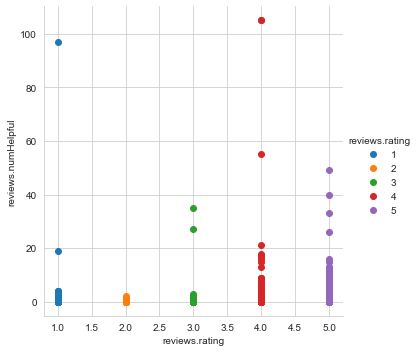

In [6]:

sns.set_style('whitegrid')   ## Background Grid
sns.FacetGrid(df, hue = 'reviews.rating', size = 5).map(plt.scatter, 'reviews.rating', 'reviews.numHelpful').add_legend()

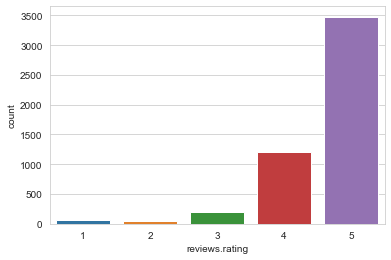

In [7]:
sns.countplot(data=df, x = 'reviews.rating', label='Count') 

## Asins (Amazon Standard Identification Number) unique id of the items Computers,Electronics Features,Tablets etc

In [8]:
asins_unique = len(data["asins"].unique()) 
print("Number of Unique ASINs: " + str(asins_unique))

Number of Unique ASINs: 24


In [9]:
print(data['name'])

0       Amazon Kindle E-Reader 6" Wifi (8th Generation...
1       Amazon Kindle E-Reader 6" Wifi (8th Generation...
2       Amazon Kindle E-Reader 6" Wifi (8th Generation...
3       Amazon Kindle E-Reader 6" Wifi (8th Generation...
4       Amazon Kindle E-Reader 6" Wifi (8th Generation...
                              ...                        
4995    Fire Tablet with Alexa, 7" Display, 16 GB, Mag...
4996    Fire Tablet with Alexa, 7" Display, 16 GB, Mag...
4997    Fire Tablet with Alexa, 7" Display, 16 GB, Mag...
4998    Fire Tablet with Alexa, 7" Display, 16 GB, Mag...
4999    Fire Tablet with Alexa, 7" Display, 16 GB, Mag...
Name: name, Length: 5000, dtype: object


In [10]:
print(data['brand'])

0       Amazon
1       Amazon
2       Amazon
3       Amazon
4       Amazon
         ...  
4995    Amazon
4996    Amazon
4997    Amazon
4998    Amazon
4999    Amazon
Name: brand, Length: 5000, dtype: object


In [11]:
print(data['reviews.title'])

0                                          Too small
1       Great light reader. Easy to use at the beach
2                                Great for the price
3                                        A Great Buy
4           Solid entry-level Kindle. Great for kids
                            ...                     
4995                                    Good product
4996                                    Great Tablet
4997                 Great for kids or smaller needs
4998                    Very sturdy for a 5 year old
4999                             great little tablet
Name: reviews.title, Length: 5000, dtype: object


## Split into Train/Test

In [12]:
print("Before {}".format(len(data)))
dataAfter = data.dropna(subset=["reviews.rating"]) 
print("After {}".format(len(dataAfter)))
dataAfter["reviews.rating"] = dataAfter["reviews.rating"].astype(int)

Before 5000
After 5000


In [13]:
split = StratifiedShuffleSplit(n_splits=5, test_size=0.2)
for train_index, test_index in split.split(dataAfter, dataAfter["reviews.rating"]): 
    strat_train = dataAfter.reindex(train_index)
    strat_test = dataAfter.reindex(test_index)

In [14]:
len(strat_train), len(strat_test)


(4000, 1000)

In [15]:
strat_train["reviews.rating"].value_counts()/len(strat_train)

5    0.69575
4    0.24150
3    0.03950
1    0.01250
2    0.01075
Name: reviews.rating, dtype: float64

## Data Exploration (Training Set) [cleanning of data]

In [16]:
reviews = strat_train.copy()
reviews.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.dateSeen,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
2555,AVpgdkC8ilAPnD_xsvyi,2016-04-10T22:00:34Z,2018-09-21T18:45:21Z,"Fire Tablet, 7 Display, Wi-Fi, 16 GB - Include...",B018Y22BI4,Amazon,"Fire Tablets,Computers/Tablets & Networking,Ta...",Electronics,http://i.ebayimg.com/thumbs/images/g/3MIAAOSwo...,amazonfire16gb5thgen2015releaseblack/272201222...,...,"2017-09-03T00:00:00Z,2017-08-27T00:00:00Z,2017...",True,NaN,0,5,http://reviews.bestbuy.com/3545/5023200/review...,Bought this to carry around for Internet and g...,1st time user,Lakle,http://reviews.bestbuy.com/3545/5023200/review...
4118,AVqkIhwDv8e3D1O-lebb,2017-03-06T14:59:43Z,2018-02-13T21:53:06Z,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Electronics,https://i5.walmartimages.com/asr/c494506a-b347...,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",...,2017-06-07T09:03:00.000Z,True,NaN,0,5,http://reviews.bestbuy.com/3545/5620406/review...,I bought this tab for my daughter's birthday.i...,Awesome little tab!,Maggie,http://www.walmart.com/ip/All-New-Fire-HD-8-Ta...
807,AWK8z0pOIwln0LfXlSxH,2018-04-13T02:03:15Z,2018-10-15T15:46:03Z,Amazon Echo Show Alexa-enabled Bluetooth Speak...,B01J24C0TI,Amazon,"Amazon Echo,Virtual Assistant Speakers,Electro...","Electronics,Hardware",https://pisces.bbystatic.com/image2/BestBuy_US...,amazonechoshowsmartspeakerwithalexablack/58756...,...,2018-05-27T00:00:00Z,True,NaN,0,5,https://reviews.bestbuy.com/3545/5875662/revie...,Great product and it is very easy to set up an...,love it,tc13,https://reviews.bestbuy.com/3545/5875662/revie...
4170,AVqkIhwDv8e3D1O-lebb,2017-03-06T14:59:43Z,2018-02-13T21:53:06Z,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Electronics,https://i5.walmartimages.com/asr/c494506a-b347...,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",...,2017-06-07T09:03:00.000Z,True,NaN,0,5,http://reviews.bestbuy.com/3545/5620406/review...,This screen on the hd8 is a huge improvement o...,Great hd screen,julio,http://www.walmart.com/ip/All-New-Fire-HD-8-Ta...
983,AWMjT0WguC1rwyj_rFh3,2018-05-02T14:01:51Z,2018-09-21T19:44:16Z,Amazon - Echo Plus w/ Built-In Hub - Silver,B06XB29FPF,Amazon,"Amazon Echo,Smart Home,Networking,Home & Tools...","Electronics,Hardware",https://pisces.bbystatic.com/image2/BestBuy_US...,amazonamazonechoplussmartspeakerwithalexaphili...,...,2018-04-26T00:00:00Z,True,NaN,0,5,https://reviews.bestbuy.com/3545/6036024/revie...,"bought this as a present for the wife, but as ...",like a personal concierge,classicman,https://www.newegg.com/Product/Product.aspx%25...


In [17]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4000 entries, 2555 to 4562
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   4000 non-null   object 
 1   dateAdded            4000 non-null   object 
 2   dateUpdated          4000 non-null   object 
 3   name                 4000 non-null   object 
 4   asins                4000 non-null   object 
 5   brand                4000 non-null   object 
 6   categories           4000 non-null   object 
 7   primaryCategories    4000 non-null   object 
 8   imageURLs            4000 non-null   object 
 9   keys                 4000 non-null   object 
 10  manufacturer         4000 non-null   object 
 11  manufacturerNumber   4000 non-null   object 
 12  reviews.date         4000 non-null   object 
 13  reviews.dateAdded    838 non-null    object 
 14  reviews.dateSeen     4000 non-null   object 
 15  reviews.doRecommend  4000 non-null 

In [18]:
len(reviews["name"].unique()), len(reviews["asins"].unique())

(23, 24)

In [19]:
reviews.groupby('asins')['name'].unique()

asins
B00IOY8XWQ          [Amazon - Kindle Voyage - 6" - 4GB - Black]
B00IOYAM4I    [Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - B...
B00QFQRELG    [Amazon 9W PowerFast Official OEM USB Charger ...
B00REQKWGA    [Kindle Oasis E-reader with Leather Charging C...
B00VINDBJK    [Kindle Oasis E-reader with Leather Charging C...
B00ZV9PXP2    [Amazon Kindle E-Reader 6" Wifi (8th Generatio...
B010CEHQTG    [Amazon Echo Show Alexa-enabled Bluetooth Spea...
B017JG41PC    [Kindle E-reader - White, 6 Glare-Free Touchsc...
B0189XYY0Q    [Fire HD 10 Tablet, 10.1 HD Display, Wi-Fi, 16...
B018Y224PY    [Fire Tablet with Alexa, 7" Display, 16 GB, Ma...
B018Y225IA    [Brand New Amazon Kindle Fire 16gb 7" Ips Disp...
B018Y22BI4    [Fire Tablet, 7 Display, Wi-Fi, 16 GB - Includ...
B018Y22C2Y    [Fire Kids Edition Tablet, 7 Display, Wi-Fi, 1...
B018Y23MNM    [Fire Kids Edition Tablet, 7 Display, Wi-Fi, 1...
B01ACEKAJY    [All-New Fire HD 8 Tablet, 8" HD Display, Wi-F...
B01AHB9C1E    [Fire HD 8 Tablet wi

In [20]:
different_name = reviews[reviews['asins'] == "B018Y225IA,B01AHBDCKQ"]["name"].unique()
for name in different_name:
    print(name)

In [21]:
reviews[reviews['asins'] == "B018Y225IA,B01AHBDCKQ"]["name"].value_counts()

Series([], Name: name, dtype: int64)

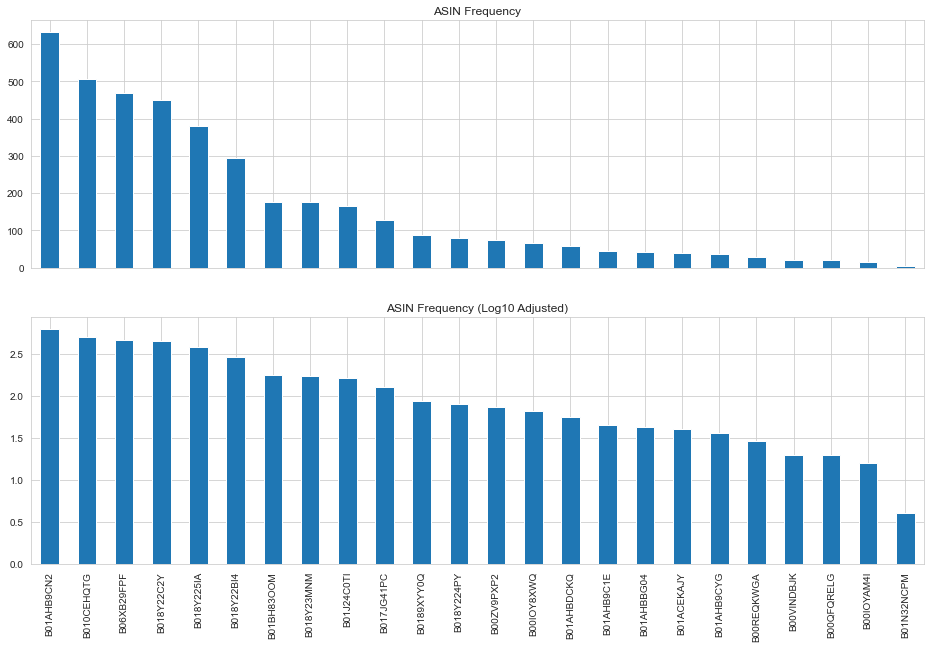

In [22]:
fig = plt.figure(figsize=(16,10))
ax1 = plt.subplot(211)
ax2 = plt.subplot(212, sharex = ax1)


## 1
reviews["asins"].value_counts().plot(kind="bar", ax=ax1, title="ASIN Frequency")


##2
np.log10(reviews["asins"].value_counts()).plot(kind="bar", ax=ax2, title="ASIN Frequency (Log10 Adjusted)") 
plt.show() 

#### Entire training dataset average rating

In [23]:
reviews["reviews.rating"].mean()

4.59725

### Review.Rating / ASINs

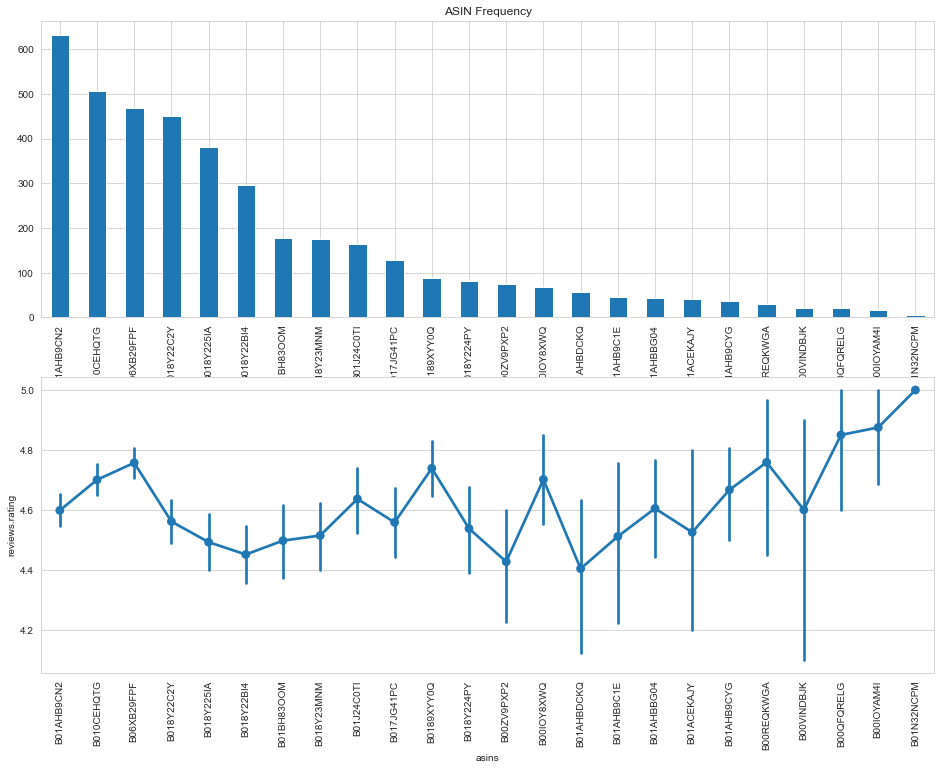

In [24]:
asins_count_ix= reviews['asins'].value_counts().index

plt.subplots(2,1,figsize=(16,12))
plt.subplot(2,1,1)

reviews["asins"].value_counts().plot(kind="bar", title="ASIN Frequency")

plt.subplot(2,1,2)
sns.pointplot(x="asins", y="reviews.rating", order=asins_count_ix, data=reviews)
plt.xticks(rotation=90)
plt.show()

## Correlations

#### Here we can analyze reviews.ratings with asins

In [25]:
corr_matrix = reviews.corr()
corr_matrix 

,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating
reviews.doRecommend,1.000000,0.597526,-0.058380,0.646972
reviews.id,0.597526,1.000000,-0.746694,0.801587
reviews.numHelpful,-0.058380,-0.746694,1.000000,-0.070335
reviews.rating,0.646972,0.801587,-0.070335,1.000000


In [26]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4000 entries, 2555 to 4562
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   4000 non-null   object 
 1   dateAdded            4000 non-null   object 
 2   dateUpdated          4000 non-null   object 
 3   name                 4000 non-null   object 
 4   asins                4000 non-null   object 
 5   brand                4000 non-null   object 
 6   categories           4000 non-null   object 
 7   primaryCategories    4000 non-null   object 
 8   imageURLs            4000 non-null   object 
 9   keys                 4000 non-null   object 
 10  manufacturer         4000 non-null   object 
 11  manufacturerNumber   4000 non-null   object 
 12  reviews.date         4000 non-null   object 
 13  reviews.dateAdded    838 non-null    object 
 14  reviews.dateSeen     4000 non-null   object 
 15  reviews.doRecommend  4000 non-null 

In [27]:
counts = reviews['asins'].value_counts().to_frame()
counts.head()

,asins
B01AHB9CN2,632
B010CEHQTG,507
B06XB29FPF,469
B018Y22C2Y,451
B018Y225IA,380


In [28]:
avg_rating = reviews.groupby("asins")["reviews.rating"].mean().to_frame()
avg_rating.head()

,reviews.rating
asins,
B00IOY8XWQ,4.701493
B00IOYAM4I,4.875000
B00QFQRELG,4.850000
B00REQKWGA,4.758621
B00VINDBJK,4.600000


In [29]:
table = counts.join(avg_rating)
table.head()

,asins,reviews.rating
B01AHB9CN2,632,4.598101
B010CEHQTG,507,4.700197
B06XB29FPF,469,4.756930
B018Y22C2Y,451,4.560976
B018Y225IA,380,4.492105


,asins,reviews.rating
asins,1.000000,-0.163983
reviews.rating,-0.163983,1.000000


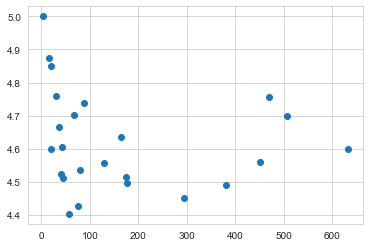

In [30]:
plt.scatter("asins", "reviews.rating", data=table)
table.corr()

# SENTIMENTAL ANALYSIS 

### Set Target Variable (Sentiments)

In [31]:
def sentiments(rating):
    if (rating == 5) or (rating == 4):
        return "Positive"
    elif rating == 3:
        return "Neutral"
    elif (rating == 2) or (rating == 1):
        return "Negative"
# Add sentiments to the data
strat_train["Sentiment"] = strat_train["reviews.rating"].apply(sentiments)
strat_test["Sentiment"] = strat_test["reviews.rating"].apply(sentiments)
strat_train["Sentiment"][:20]

2555    Positive
4118    Positive
807     Positive
4170    Positive
983     Positive
861      Neutral
1985    Positive
1674    Positive
4276    Positive
3031    Positive
4167    Positive
2683    Positive
4866    Positive
3565    Positive
4451    Positive
3412    Positive
1374    Positive
3344    Positive
2754    Positive
2537    Positive
Name: Sentiment, dtype: object

### Prepare data

In [32]:

##x
X_train = strat_train["reviews.text"]

## y
X_train_targetSentiment = strat_train["Sentiment"]


X_test = strat_test["reviews.text"]

X_test_targetSentiment = strat_test["Sentiment"]

print(len(X_train), len(X_test))

4000 1000


### Replace "nan" with space

In [33]:


X_train = X_train.fillna(' ')
X_test = X_test.fillna(' ')



X_train_targetSentiment = X_train_targetSentiment.fillna(' ')
X_test_targetSentiment = X_test_targetSentiment.fillna(' ')


### Text preprocessing and occurance counting

In [34]:

count_vect = CountVectorizer()
X_train_counts = count_vect.fit_transform(X_train) 
X_train_counts.shape

(4000, 4977)

In [35]:

tfidf_transformer = TfidfTransformer(use_idf=False)
X_train_tfidf = tfidf_transformer.fit_transform(X_train_counts) ## y
X_train_tfidf.shape

(4000, 4977)

# Building a Pipeline from the Extracted Features

In [36]:

clf_multiNB_pipe = Pipeline([("vect", CountVectorizer()), ("tfidf", TfidfTransformer()), ("clf_nominalNB", MultinomialNB())])
clf_multiNB_pipe.fit(X_train, X_train_targetSentiment)

Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf_nominalNB', MultinomialNB())])

# Test Model

In [37]:
predictedMultiNB = clf_multiNB_pipe.predict(X_test)
np.mean(predictedMultiNB == X_test_targetSentiment)

0.937

In [38]:

clf_logReg_pipe = Pipeline([("vect", CountVectorizer()), ("tfidf", TfidfTransformer()), ("clf_logReg", LogisticRegression())])
clf_logReg_pipe.fit(X_train, X_train_targetSentiment)


predictedLogReg = clf_logReg_pipe.predict(X_test)
np.mean(predictedLogReg == X_test_targetSentiment)

0.938

# Testing Other Models

**Logistic Regression Classifier**

In [39]:


clf_logReg_pipe = Pipeline([("vect", CountVectorizer()), ("tfidf", TfidfTransformer()), ("clf_logReg", LogisticRegression())])
clf_logReg_pipe.fit(X_train, X_train_targetSentiment)


predictedLogReg = clf_logReg_pipe.predict(X_test)
np.mean(predictedLogReg == X_test_targetSentiment)

0.938

**Support Vector Machine Classifier**

In [40]:

clf_linearSVC_pipe = Pipeline([("vect", CountVectorizer()), ("tfidf", TfidfTransformer()), ("clf_linearSVC", LinearSVC())])
clf_linearSVC_pipe.fit(X_train, X_train_targetSentiment)

predictedLinearSVC = clf_linearSVC_pipe.predict(X_test)
np.mean(predictedLinearSVC == X_test_targetSentiment)

0.948

**Random Forest Classifier**

In [41]:

clf_randomForest_pipe = Pipeline([("vect", CountVectorizer()), ("tfidf", TfidfTransformer()), ("clf_randomForest", RandomForestClassifier())])
clf_randomForest_pipe.fit(X_train, X_train_targetSentiment)

predictedRandomForest = clf_randomForest_pipe.predict(X_test)
np.mean(predictedRandomForest == X_test_targetSentiment)

0.948

## Fine tuning the Support Vector Machine Classifier

In [42]:

parameters = {'vect__ngram_range': [(1, 1), (1, 2)],    
             'tfidf__use_idf': (True, False), 
             } 



gs_clf_LinearSVC_pipe = GridSearchCV(clf_linearSVC_pipe, parameters, n_jobs=-1)
gs_clf_LinearSVC_pipe = gs_clf_LinearSVC_pipe.fit(X_train, X_train_targetSentiment)



new_text = ["The tablet is good, really liked it.", # positive
            "The tablet is ok, but it works fine.", # neutral
            "The tablet is not good, does not work very well."] # negative

X_train_targetSentiment[gs_clf_LinearSVC_pipe.predict(new_text)]

Positive    NaN
Neutral     NaN
Neutral     NaN
Name: Sentiment, dtype: object

In [43]:
predictedGS_clf_LinearSVC_pipe = gs_clf_LinearSVC_pipe.predict(X_test)
np.mean(predictedGS_clf_LinearSVC_pipe == X_test_targetSentiment)

0.947

## Detailed Performance Analysis of Support Vector Machine Classifier

In [44]:
for performance_analysis in (gs_clf_LinearSVC_pipe.best_score_, 
                             gs_clf_LinearSVC_pipe.best_estimator_, 
                             gs_clf_LinearSVC_pipe.best_params_):
        print(performance_analysis)

0.95075
Pipeline(steps=[('vect', CountVectorizer(ngram_range=(1, 2))),
                ('tfidf', TfidfTransformer()), ('clf_linearSVC', LinearSVC())])
{'tfidf__use_idf': True, 'vect__ngram_range': (1, 2)}


In [45]:

print(classification_report(X_test_targetSentiment, predictedGS_clf_LinearSVC_pipe))
print('Accuracy: {}'. format(accuracy_score(X_test_targetSentiment, predictedGS_clf_LinearSVC_pipe)))

              precision    recall  f1-score   support

    Negative       1.00      0.29      0.45        24
     Neutral       1.00      0.08      0.14        39
    Positive       0.95      1.00      0.97       937

    accuracy                           0.95      1000
   macro avg       0.98      0.46      0.52      1000
weighted avg       0.95      0.95      0.93      1000

Accuracy: 0.947


In [46]:
metrics.confusion_matrix(X_test_targetSentiment, predictedGS_clf_LinearSVC_pipe)

array([[  7,   0,  17],
       [  0,   3,  36],
       [  0,   0, 937]], dtype=int64)